## Clustering of physicochemical interface description
We apply the methods
* The VBGMM implementaion by P. Sykacek as provided in ../ppi.lib/vbgmm.py
* The Gaussian mixture in sklearn (sklearn.mixture.GaussianMixture) with cross validated optimal cluster numbers
* Clustering by the affinity propagation approach in sklearn (sklearn.cluster.AffinityPropagation) where we set the parameters such as to obtain a clustering in the range of what is found suitable by both GMM implementations.
## Clustering of property specific features
We start by clustering the 64 property specific features which were mapped from residue specific values to interface specific values by standard aggregation methods.
## Load data and initialisations 

../course.lib/:./::/home/psykacek/sciwrk/py3libs


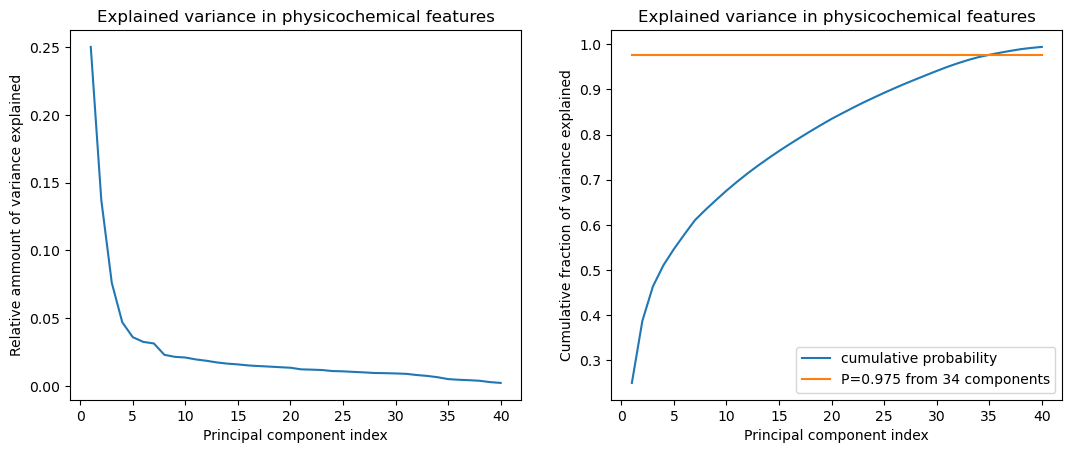

In [1]:
## turn off warnings
from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
simplefilter("ignore", category=ConvergenceWarning)
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["PYTHONWARNINGS"] = "ignore" # Also affect subprocesses
## initialise kernel-engine with standard libraries
import numpy as np
import pandas as pd
# set the basepath to "one up"
basepath="../"
## set the path
import sys
sys.path.append(basepath+"ppi.lib/")
os.environ["PYTHONPATH"]=basepath+"ppi.lib/:./:"+os.environ["PYTHONPATH"]
print(os.environ["PYTHONPATH"])
import ml_lib as mlib
import importlib
importlib.reload(mlib)

## Load the classically aggregated amino acid physico chemical PPI interaction features
(X, y, ftrnams, sampleids)=mlib.extract4ml()
from sklearn.preprocessing import StandardScaler as SSC
## we transform the data as a whole
Xtr=SSC().fit_transform(X)
## convert the labels
from sklearn.preprocessing import LabelEncoder as LBE
ytr=LBE().fit_transform(y)
## we work now with Xtr (and ytr)

## apply PCA to diagnose correlation
from sklearn.decomposition import PCA
pca=PCA()
Xp=pca.fit_transform(Xtr)
expvar=pca.explained_variance_
expvarfrac=pca.explained_variance_ratio_
xc=np.arange(len(expvar))+1
max4vis=40
import matplotlib.pyplot as plt
plt.figure(figsize=[6.4*2, 4.8])
plt.subplot(1,2,1)
plt.plot(xc[:max4vis], expvarfrac[:max4vis])
plt.title("Explained variance in physicochemical features")
plt.ylabel("Relative ammount of variance explained")
plt.xlabel("Principal component index")
plt.subplot(1,2,2)
cumP=mlib.cumprob(expvarfrac, dosort=False)[0] ## cumprob[1] provides the indices if we sort
plt.plot(xc[:max4vis], cumP[:max4vis], label="cumulative probability")
plt.title("Explained variance in physicochemical features")
plt.ylabel("Cumulative fraction of variance explained")
plt.xlabel("Principal component index")
ncomponents_suggested=np.sum(cumP <=0.975)
plt.plot([1,np.min([max4vis, np.max(xc)])],[0.975, 0.975], label="P=0.975 from {0} components".format(ncomponents_suggested))
plt.legend()
plt.show()


In [2]:
## the above plot suggests extracting 34 principal components and cluster those

pca=PCA(n_components=ncomponents_suggested)
Xp=pca.fit_transform(Xtr)

from sklearn.preprocessing import StandardScaler as SSC
## we transform the data as a whole
Xtr=SSC().fit_transform(Xp)
## convert the labels
from sklearn.preprocessing import LabelEncoder as LBE
ytr=LBE().fit_transform(y)
## we work now with Xtr (and ytr for evaluation)

In [3]:
retran=50    ## number of repetitions of inference runs for every setting
## load vbgmm 
import vbgmm
importlib.reload(vbgmm)
maxclust=20  ## number of Gaussian components tested
## only one type of covariance structure with up to maxclust kernels 
## we set the prior counts for the kernel weight parameter to 5. and 
## use a full covarianve matrix for every kernel 
paramgrid={"nK":list(range(maxclust, 0, -1)), "PIndPriCnt":[5], "covtyp":["full"], 
           "covmode":["individual"], "kmnsinit":[20]}
## construct a vb inference engine which iterates in parallel over all hyper parameter combinations
## infers retran models with every setting and retains the best model per setting.
bayesmdl=vbgmm.ProbEns(vbgmm.SERIALLEARNER, paramgrid, ninit=retran, ncpus=-1, rayargs={"runtime_env":{"working_dir": "./"}})
bayesmdl.fit(Xtr)
## we can now evaluate the inference result.
scorestats=bayesmdl.getscorestats()
## final cleanup
bayesmdl.stopparproc()
## we are now done and convert the scorestats dictionary to a pandas dataframe
vbmdlstats=pd.DataFrame(scorestats)
fnam="../results/classical_agg_34_vbgmmstats.csv"
mlib.creapath(fnam)
vbmdlstats.to_csv(fnam, index=False)
## 1) Extract allocation probabilities of the optimal model 
## bayesmdl.predict_proba() provides the correct interface.
QIn=bayesmdl.predict_proba().copy()
## store data and labels as binary files
mlib.writeallocs("../results/classical_agg_34_vbgmm", QIn, ytr)

initi self.rayargs
1000
1000


In [4]:
## using an elbow argument, the above plot suggests extracting at most 10 principal components and cluster those
ncomponents_suggested=10
pca=PCA(n_components=ncomponents_suggested)
Xp=pca.fit_transform(Xtr)

from sklearn.preprocessing import StandardScaler as SSC
## we transform the data as a whole
Xtr=SSC().fit_transform(Xp)
## convert the labels
from sklearn.preprocessing import LabelEncoder as LBE
ytr=LBE().fit_transform(y)
## we work now with Xtr (and ytr for evaluation)

In [5]:
retran=50    ## number of repetitions of inference runs for every setting
## load vbgmm 
import vbgmm
importlib.reload(vbgmm)
maxclust=15  ## number of Gaussian components tested
## only one type of covariance structure with up to maxclust kernels 
## we set the prior counts for the kernel weight parameter to 5. and 
## use a full covarianve matrix for every kernel 
paramgrid={"nK":list(range(maxclust, 0, -1)), "PIndPriCnt":[5], "covtyp":["full"], 
           "covmode":["individual"], "kmnsinit":[20]}
## construct a vb inference engine which iterates in parallel over all hyper parameter combinations
## infers retran models with every setting and retains the best model per setting.
bayesmdl=vbgmm.ProbEns(vbgmm.SERIALLEARNER, paramgrid, ninit=retran, ncpus=-1, rayargs={"runtime_env":{"working_dir": "./"}})
bayesmdl.fit(Xtr)
## we can now evaluate the inference result.
scorestats=bayesmdl.getscorestats()
## final cleanup
bayesmdl.stopparproc()
## we are now done and convert the scorestats dictionary to a pandas dataframe
vbmdlstats=pd.DataFrame(scorestats)
fnam="../results/classical_agg_10_vbgmmstats.csv"
mlib.creapath(fnam)
vbmdlstats.to_csv(fnam, index=False)
## 1) Extract allocation probabilities of the optimal model 
## bayesmdl.predict_proba() provides the correct interface.
QIn=bayesmdl.predict_proba().copy()
## store data and labels as binary files
mlib.writeallocs("../results/classical_agg_10_vbgmm", QIn, ytr)

initi self.rayargs
750
750


## Unsupervised analysis of GNN embeddings
As we observe most information about the transmembran status contained in the data which is based on set-to-set pooling, we analyse the corresponding embedded sample representation. 

../course.lib/:./:../course.lib/:./::/home/psykacek/sciwrk/py3libs


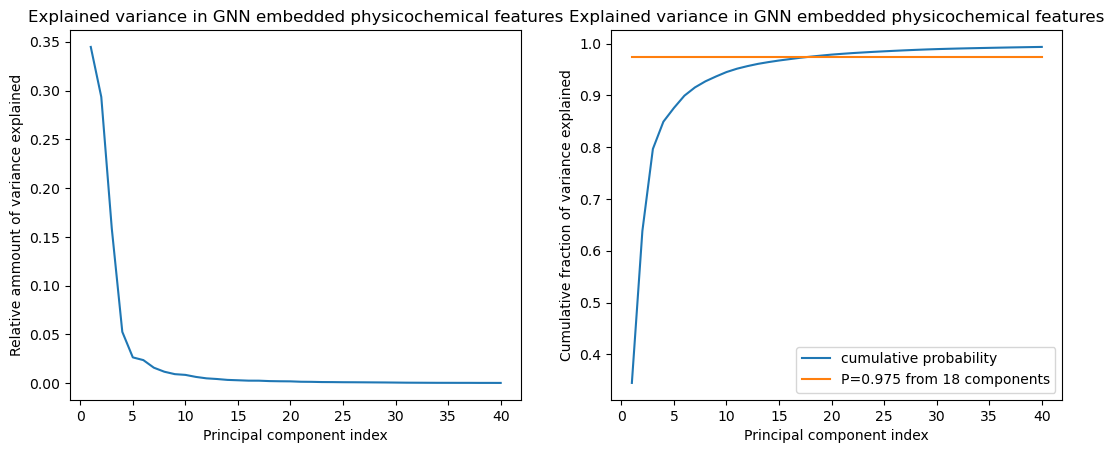

In [6]:
## turn off warnings
from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
simplefilter("ignore", category=ConvergenceWarning)
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["PYTHONWARNINGS"] = "ignore" # Also affect subprocesses
## initialise kernel-engine with standard libraries
import numpy as np
import pandas as pd
# set the basepath to "one up"
basepath="../"
## set the path
import sys
sys.path.append(basepath+"ppi.lib/")
os.environ["PYTHONPATH"]=basepath+"ppi.lib/:./:"+os.environ["PYTHONPATH"]
print(os.environ["PYTHONPATH"])
import ml_lib as mlib
import importlib
importlib.reload(mlib)
## we use the default parameters which loads mlib.embed_fnam_s2s="../source/GNN_set2set_ALL_FOLDS.csv"
(X, y, ftrnams, sampleids)=mlib.ext_gnn_preds()

## scale and PCA transform
from sklearn.preprocessing import StandardScaler as SSC
## we transform the data as a whole
Xtr=SSC().fit_transform(X)
## convert the labels
from sklearn.preprocessing import LabelEncoder as LBE
ytr=LBE().fit_transform(y)
## we work now with Xtr (and ytr)

## apply PCA to diagnose correlation
from sklearn.decomposition import PCA
pca=PCA()
Xp=pca.fit_transform(Xtr)
expvar=pca.explained_variance_
expvarfrac=pca.explained_variance_ratio_
xc=np.arange(len(expvar))+1
max4vis=40
import matplotlib.pyplot as plt
plt.figure(figsize=[6.4*2, 4.8])
plt.subplot(1,2,1)
plt.plot(xc[:max4vis], expvarfrac[:max4vis])
plt.title("Explained variance in GNN embedded physicochemical features")
plt.ylabel("Relative ammount of variance explained")
plt.xlabel("Principal component index")
plt.subplot(1,2,2)
cumP=mlib.cumprob(expvarfrac, dosort=False)[0] ## cumprob[1] provides the indices if we sort
plt.plot(xc[:max4vis], cumP[:max4vis], label="cumulative probability")
plt.title("Explained variance in GNN embedded physicochemical features")
plt.ylabel("Cumulative fraction of variance explained")
plt.xlabel("Principal component index")
ncomponents_suggested=np.sum(cumP <=0.975)
plt.plot([1,np.min([max4vis, np.max(xc)])],[0.975, 0.975], label="P=0.975 from {0} components".format(ncomponents_suggested))
plt.legend()
plt.show()


In [7]:
## the above plot suggests extracting 18 principal components and cluster those
pca=PCA(n_components=ncomponents_suggested)
Xp=pca.fit_transform(Xtr)

from sklearn.preprocessing import StandardScaler as SSC
## we transform the data as a whole
Xtr=SSC().fit_transform(Xp)
## convert the labels
from sklearn.preprocessing import LabelEncoder as LBE
ytr=LBE().fit_transform(y)
## we work now with Xtr (and ytr for evaluation)

In [9]:
retran=50    ## number of repetitions of inference runs for every setting
## load vbgmm 
import vbgmm
importlib.reload(vbgmm)
maxclust=22  ## number of Gaussian components tested
## only one type of covariance structure with up to maxclust kernels 
## we set the prior counts for the kernel weight parameter to 5. and 
## use a full covarianve matrix for every kernel 
paramgrid={"nK":list(range(maxclust, 0, -1)), "PIndPriCnt":[5], "covtyp":["full"], 
           "covmode":["individual"], "kmnsinit":[20]}
## construct a vb inference engine which iterates in parallel over all hyper parameter combinations
## infers retran models with every setting and retains the best model per setting.
bayesmdl=vbgmm.ProbEns(vbgmm.SERIALLEARNER, paramgrid, ninit=retran, ncpus=-1, rayargs={"runtime_env":{"working_dir": "./"}})
bayesmdl.fit(Xtr)
## we can now evaluate the inference result.
scorestats=bayesmdl.getscorestats()
## final cleanup
bayesmdl.stopparproc()
## we are now done and convert the scorestats dictionary to a pandas dataframe
vbmdlstats=pd.DataFrame(scorestats)
fnam="../results/GNN_s2s_18_vbgmmstats.csv"
mlib.creapath(fnam)
vbmdlstats.to_csv(fnam, index=False)
## 1) Extract allocation probabilities of the optimal model 
## bayesmdl.predict_proba() provides the correct interface.
QIn=bayesmdl.predict_proba().copy()
## store data and labels as binary files
mlib.writeallocs("../results/GNN_s2s_18_vbgmm", QIn, ytr)

initi self.rayargs
1100
1100


In [10]:
## using an ellbow argument, the above plot suggests extracting at most 10 principal components and cluster those
ncomponents_suggested=10
pca=PCA(n_components=ncomponents_suggested)
Xp=pca.fit_transform(Xtr)

from sklearn.preprocessing import StandardScaler as SSC
## we transform the data as a whole
Xtr=SSC().fit_transform(Xp)
## convert the labels
from sklearn.preprocessing import LabelEncoder as LBE
ytr=LBE().fit_transform(y)
## we work now with Xtr (and ytr for evaluation)

In [11]:
retran=50    ## number of repetitions of inference runs for every setting
## load vbgmm 
import vbgmm
importlib.reload(vbgmm)
maxclust=22  ## number of Gaussian components tested
## only one type of covariance structure with up to maxclust kernels 
## we set the prior counts for the kernel weight parameter to 5. and 
## use a full covarianve matrix for every kernel 
paramgrid={"nK":list(range(maxclust, 0, -1)), "PIndPriCnt":[5], "covtyp":["full"], 
           "covmode":["individual"], "kmnsinit":[20]}
## construct a vb inference engine which iterates in parallel over all hyper parameter combinations
## infers retran models with every setting and retains the best model per setting.
bayesmdl=vbgmm.ProbEns(vbgmm.SERIALLEARNER, paramgrid, ninit=retran, ncpus=-1, rayargs={"runtime_env":{"working_dir": "./"}})
bayesmdl.fit(Xtr)
## we can now evaluate the inference result.
scorestats=bayesmdl.getscorestats()
## final cleanup
bayesmdl.stopparproc()
## we are now done and convert the scorestats dictionary to a pandas dataframe
vbmdlstats=pd.DataFrame(scorestats)
fnam="../results/GNN_s2s_10_vbgmmstats.csv"
mlib.creapath(fnam)
vbmdlstats.to_csv(fnam, index=False)
## 1) Extract allocation probabilities of the optimal model 
## bayesmdl.predict_proba() provides the correct interface.
QIn=bayesmdl.predict_proba().copy()
## store data and labels as binary files
mlib.writeallocs("../results/GNN_s2s_10_vbgmm", QIn, ytr)

initi self.rayargs
1100
1100


## Clusters from GSCV based hyperparameteroptimisation
To test the validity fo the ptoposed cluster numbers with a second approach we use scikit-learn and assess the number of clusters of full covariance GMMs with grid search cross validation (GSCV).
## Analysis of physicochemical interface features from classical aggregation  

In [12]:
## turn off warnings
from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
simplefilter("ignore", category=ConvergenceWarning)
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["PYTHONWARNINGS"] = "ignore" # Also affect subprocesses
## initialise kernel-engine with standard libraries
import numpy as np
import pandas as pd
# set the basepath to "one up"
basepath="../"
## set the path
import sys
sys.path.append(basepath+"ppi.lib/")
os.environ["PYTHONPATH"]=basepath+"ppi.lib/:./:"+os.environ["PYTHONPATH"]
print(os.environ["PYTHONPATH"])
import ml_lib as mlib
import importlib
importlib.reload(mlib)

## Load the classically aggregated amino acid physico chemical PPI interaction features
(X, y, ftrnams, sampleids)=mlib.extract4ml()
from sklearn.preprocessing import StandardScaler as SSC
## we transform the data as a whole
Xtr=SSC().fit_transform(X)
## convert the labels
from sklearn.preprocessing import LabelEncoder as LBE
ytr=LBE().fit_transform(y)
## we work now with Xtr (and ytr)

## apply PCA to diagnose correlation
from sklearn.decomposition import PCA
## GSCV is again based on the ellbow argument which suggests to take approximately 10 PCs
ncomponents_suggested=10 
pca=PCA(n_components=ncomponents_suggested)
Xp=pca.fit_transform(Xtr)

from sklearn.preprocessing import StandardScaler as SSC
## we transform the data as a whole
Xtr=SSC().fit_transform(Xp)
## convert the labels
from sklearn.preprocessing import LabelEncoder as LBE
ytr=LBE().fit_transform(y)
## we work now with Xtr (and ytr for evaluation)
maxclust=25
retran=100
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV as GSCV
from sklearn.mixture import GaussianMixture as GMM

nfolds=20
kf=KFold(n_splits=nfolds, shuffle=True)
paramgrid={"n_components":list(range(maxclust, 0, -1)), "covariance_type":['full']}
gmm=GMM(n_init=retran)
gscv=GSCV(gmm, paramgrid, n_jobs=-1, cv=kf)
gscv.fit(Xtr)
## after fitting we write the score statistics
resdict=mlib.gscvscores2modeleval(gscv)

dfrm=pd.DataFrame(resdict)
fnam="../results/classical_agg_10_GMM_score.csv"
mlib.creapath(fnam)
dfrm.to_csv(fnam, index=False)
## we can finally calculate the GMM based allocation probabilities and write them to numpy matrix files.
gmm=gscv.best_estimator_

Pk=mlib.sklearngmmallocP(gmm, Xtr)
Ptst=gmm.predict_proba(Xtr)
kl=mlib.kldisc(Pk, Ptst)
print(np.mean(kl))
mlib.writeallocs("../results/classical_agg_10_GMM", Pk, ytr)

../course.lib/:./:../course.lib/:./:../course.lib/:./::/home/psykacek/sciwrk/py3libs
-4.009503936645981e-17


In [13]:
## GMM analysis for the GNN features
## we use the default parameters which loads mlib.embed_fnam_s2s="../source/GNN_set2set_ALL_FOLDS.csv"

(X, y, ftrnams, sampleids)=mlib.ext_gnn_preds()
from sklearn.preprocessing import StandardScaler as SSC
## we transform the data as a whole
Xtr=SSC().fit_transform(X)
## convert the labels
from sklearn.preprocessing import LabelEncoder as LBE
ytr=LBE().fit_transform(y)
## we work now with Xtr (and ytr)

## apply PCA to diagnose correlation
from sklearn.decomposition import PCA
## GSCV is again based on the ellbow argument which suggests to take approximately 10 PCs
ncomponents_suggested=10 
pca=PCA(n_components=ncomponents_suggested)
Xp=pca.fit_transform(Xtr)

from sklearn.preprocessing import StandardScaler as SSC
## we transform the data as a whole
Xtr=SSC().fit_transform(Xp)
## convert the labels
from sklearn.preprocessing import LabelEncoder as LBE
ytr=LBE().fit_transform(y)
## we work now with Xtr (and ytr for evaluation)
maxclust=25
retran=100
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV as GSCV
from sklearn.mixture import GaussianMixture as GMM

nfolds=20
kf=KFold(n_splits=nfolds, shuffle=True)
paramgrid={"n_components":list(range(maxclust, 0, -1)), "covariance_type":['full']}
gmm=GMM(n_init=retran)
gscv=GSCV(gmm, paramgrid, n_jobs=-1, cv=kf)
gscv.fit(Xtr)
## after fitting we write the score statistics
resdict=mlib.gscvscores2modeleval(gscv)

dfrm=pd.DataFrame(resdict)
fnam="../results/GNN_s2s_10_GMM_score.csv"
mlib.creapath(fnam)
dfrm.to_csv(fnam, index=False)
## we can finally calculate the GMM based allocation probabilities and write them to numpy matrix files.
gmm=gscv.best_estimator_

Pk=mlib.sklearngmmallocP(gmm, Xtr)
Ptst=gmm.predict_proba(Xtr)
kl=mlib.kldisc(Pk, Ptst)
print(np.mean(kl))
mlib.writeallocs("../results/GNN_s2s_10_GMM", Pk, ytr)

-1.0737226069276173e-16
